# Script to display the proportion of ascending vs descending particles over size classes for each specific region

# Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib import colors
from matplotlib.colors import LogNorm
import seaborn as sns
import matplotlib.lines as mlines
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# Useful functions 

# Function to parse size class ranges
def parse_size_class(size_class_str):
    if '-' in size_class_str:
        return list(map(float, size_class_str.replace(' ', '').split('-')))
    else:
        return [float(size_class_str.strip()), float(size_class_str.strip())]

# Function to assign a size class
def assign_size_class(esd_um):
    for i, (low, high) in enumerate(size_class_ranges):
        if low <= esd_um <= high:
            return size_class['size_classes'][i].replace(' ', '')  # Remove extra spaces
    return None


# **Import tracks data for APERO cruise**

In [2]:
# APERO 
APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv')
APERO['cruise'] = 'APERO'
APERO['zone'] = 'North Atlantic'
APERO_tracks = APERO.drop(columns=['Unnamed: 0'])
APERO_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,48538.074003,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,859557.536536,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9388.330656,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,14976.206705,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,12366.940032,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,86.862360,20230713-042803,APERO_C5_20230713-043248-1-8413,149.314402,859.596554,81.899763,261.384615,62.452042,569.800296,23.870490,0.887168,72.414924,582002.226297,859.596554,24.930501,10.582206,2.904711,36.067138,43.897118,10766.538462,81.923077,23.230769,167.615385,144.384615,217.307692,0.904952,0.410473,0.600251,551,62.452042,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
792,94.602154,20230713-042803,APERO_C5_20230713-043301-1-8717,169.000999,239.397542,53.623205,274.000000,74.398845,569.800296,23.870490,0.887168,12.866225,50557.019943,239.397542,7.284838,2.913288,1.671898,33.266155,60.209407,832.846154,42.307692,24.769231,144.307692,119.538462,19.846154,0.859600,0.539977,0.786790,551,74.398845,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
793,106.876513,20230713-042803,APERO_C5_20230713-043322-1-9208,171.007026,402.057780,91.429246,294.500000,64.130513,569.800296,23.870490,0.887168,21.368446,127511.038493,402.057780,8.258849,5.591207,2.588733,43.980739,48.059479,3149.083333,91.125000,24.500000,176.166667,151.666667,38.583333,0.732405,0.655357,0.888611,551,64.130513,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
794,144.642565,20230713-042803,APERO_C5_20230713-043431-1-11126,84.461913,165.521745,39.600017,362.000000,-60.180652,569.800296,23.870490,0.887168,7.230796,22799.832971,165.521745,4.296724,2.222534,1.708472,14.111826,34.045029,315.222222,37.000000,23.888889,64.555556,40.666667,9.000

# **Import UVP6 size classes**

In [3]:
size_class = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/size_classes.csv', delimiter = ';')

In [4]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
APERO_tracks['size_classes'] = APERO_tracks['esd_um'].apply(assign_size_class)
APERO_tracks = APERO_tracks.sort_values(by='esd_um')
APERO_tracks['size_classes'].unique()

array(['80.6-102', '102-128', '128-161', '161-203', '203-256', '256-323',
       '323-406', '406-512', '512-645', '645-813', '813-1020',
       '1020-1290', '1290-1630', '1630-2050', '2050-2580', '3250-4100',
       '5160-6500'], dtype=object)

In [5]:
desc = APERO_tracks[APERO_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = APERO_tracks[APERO_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [6]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
15,80.6-102,4
0,102-128,96
2,128-161,73
4,161-203,56
6,203-256,46
8,256-323,61
9,323-406,36
11,406-512,29
12,512-645,32
14,645-813,22


In [7]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
11,80.6-102,3
0,102-128,72
2,128-161,55
3,161-203,57
4,203-256,43
6,256-323,36
7,323-406,24
8,406-512,12
9,512-645,1
10,645-813,2


In [8]:
nb_part_tot_APERO = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_APERO

,size_classes,desc_count,asc_count
0,80.6-102,4,3
1,102-128,96,72
2,128-161,73,55
3,161-203,56,57
4,203-256,46,43
5,256-323,61,36
6,323-406,36,24
7,406-512,29,12
8,512-645,32,1
9,645-813,22,2


In [9]:
nb_part_tot_APERO['lower_bound'] = nb_part_tot_APERO['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_tot_APERO = nb_part_tot_APERO.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_tot_APERO

,size_classes,desc_count,asc_count
0,80.6-102,4,3
1,102-128,96,72
2,128-161,73,55
3,161-203,56,57
4,203-256,46,43
5,256-323,61,36
6,323-406,36,24
7,406-512,29,12
8,512-645,32,1
9,645-813,22,2


In [10]:
nb_part_tot_APERO['nb_part_tot'] = nb_part_tot_APERO['desc_count'] + nb_part_tot_APERO['asc_count']
nb_part_tot_APERO['asc_prop_%'] = (nb_part_tot_APERO['asc_count']*100)/nb_part_tot_APERO['nb_part_tot']
nb_part_tot_APERO['desc_prop_%'] = (nb_part_tot_APERO['desc_count']*100)/nb_part_tot_APERO['nb_part_tot']
nb_part_tot_APERO = nb_part_tot_APERO[(nb_part_tot_APERO['nb_part_tot'] >= 10)]
nb_part_tot_APERO

,size_classes,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
1,102-128,96,72,168,42.857143,57.142857
2,128-161,73,55,128,42.968750,57.031250
3,161-203,56,57,113,50.442478,49.557522
4,203-256,46,43,89,48.314607,51.685393
5,256-323,61,36,97,37.113402,62.886598
6,323-406,36,24,60,40.000000,60.000000
7,406-512,29,12,41,29.268293,70.731707
8,512-645,32,1,33,3.030303,96.969697
9,645-813,22,2,24,8.333333,91.666667
10,813-1020,14,2,16,12.500000,87.500000


# **Do the same for Vlfr tracks**

In [11]:
# Vlfr 
VLFR_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv')
VLFR_tracks['cruise'] = 'vlfr'
VLFR_tracks['zone'] = 'Mediterranean Sea'
VLFR_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,167.671521,20230418-142321,vlfr_20230418-142403-1-418,94.296297,114.971982,54.343333,22.000000,-73.375225,660.192273,25.694207,0.588969,4.214214,10511.082352,114.971982,2.756337,1.484728,1.527067,17.261139,35.035069,200.000000,52.900000,34.800000,76.800000,42.000000,3.800000,0.832847,0.733333,1.000000,152,-73.375225,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-84.057856,20230501-231319,vlfr_20230501-231957-1-10371,-140.192296,195.102155,73.021077,376.500000,-56.134440,378.987625,19.467604,0.615935,8.781092,30191.027904,195.102155,4.147502,2.918092,2.116595,33.204497,44.742046,709.375000,68.375000,27.875000,129.875000,102.000000,10.000000,0.682493,0.785764,0.963542,409,-56.134440,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
462,-85.285975,20230501-231319,vlfr_20230501-232003-1-10572,-154.435880,205.712784,68.098055,383.444444,-69.149905,378.987625,19.467604,0.615935,9.418162,33517.908728,205.712784,5.373178,2.573705,1.754223,29.566250,43.793047,718.666667,64.611111,28.333333,123.444444,95.111111,12.000000,0.873998,0.737037,0.879361,409,-69.149905,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
463,-85.481231,20230501-231319,vlfr_20230501-232004-1-10588,-141.559343,191.745555,88.308025,384.555556,-56.078112,378.987625,19.467604,0.615935,8.694304,29664.313902,191.745555,4.250962,2.686470,2.037128,47.433904,54.196583,832.444444,84.055556,27.111111,170.111111,143.000000,9.666667,0.746105,0.803704,0.984127,409,-56.078112,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
464,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,12430.275503,124.717871,2.700440,1.770848,1.725997,29.818883,45.671808,287.000000,59.200000,30.000000,101.400000,71.400000,4.400000,0.642826,0.850000,1.000000,409

In [12]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
VLFR_tracks['size_classes'] = VLFR_tracks['esd_um'].apply(assign_size_class)
VLFR_tracks = VLFR_tracks.sort_values(by='esd_um')
VLFR_tracks['size_classes'].unique()

array(['80.6-102', '102-128', '128-161', '161-203', '203-256', '256-323',
       '323-406', '406-512', '512-645', '645-813', '813-1020'],
      dtype=object)

In [13]:
desc = VLFR_tracks[VLFR_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = VLFR_tracks[VLFR_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [14]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
9,80.6-102,8
0,102-128,124
1,128-161,66
2,161-203,40
3,203-256,21
4,256-323,25
5,323-406,12
6,406-512,11
7,512-645,3
8,645-813,2


In [15]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
0,102-128,36
1,128-161,39
2,161-203,38
3,203-256,27
4,256-323,9
5,323-406,3
6,645-813,1
7,813-1020,1


In [16]:
# merge both
nb_part_tot_VLFR = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_VLFR

,size_classes,desc_count,asc_count
0,102-128,124,36
1,128-161,66,39
2,161-203,40,38
3,203-256,21,27
4,256-323,25,9
5,323-406,12,3
6,645-813,2,1


In [17]:
nb_part_tot_VLFR['lower_bound'] = nb_part_tot_VLFR['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_tot_VLFR = nb_part_tot_VLFR.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_tot_VLFR

,size_classes,desc_count,asc_count
0,102-128,124,36
1,128-161,66,39
2,161-203,40,38
3,203-256,21,27
4,256-323,25,9
5,323-406,12,3
6,645-813,2,1


In [18]:
nb_part_tot_VLFR['nb_part_tot'] = nb_part_tot_VLFR['desc_count'] + nb_part_tot_VLFR['asc_count']
nb_part_tot_VLFR['asc_prop_%'] = (nb_part_tot_VLFR['asc_count']*100)/nb_part_tot_VLFR['nb_part_tot']
nb_part_tot_VLFR['desc_prop_%'] = (nb_part_tot_VLFR['desc_count']*100)/nb_part_tot_VLFR['nb_part_tot']
nb_part_tot_VLFR = nb_part_tot_VLFR[(nb_part_tot_VLFR['nb_part_tot'] >= 10)]
nb_part_tot_VLFR

,size_classes,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
0,102-128,124,36,160,22.500000,77.500000
1,128-161,66,39,105,37.142857,62.857143
2,161-203,40,38,78,48.717949,51.282051
3,203-256,21,27,48,56.250000,43.750000
4,256-323,25,9,34,26.470588,73.529412
5,323-406,12,3,15,20.000000,80.000000


# **Do the same for MBARI tracks**

In [19]:
MBARI_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_selected_tracks_by_interquartile_poly_no_living.csv')
MBARI_tracks['cruise'] = 'MBARI'
MBARI_tracks['zone'] = 'East Pacific'
MBARI_tracks

,pred_poly,r2,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,cruise,zone
0,-302.202743,0.767183,20241122-092156,MBARI_2024_deep_20241122-092222-1-43,-209.716762,319.153410,64.590580,2.250000,92.485980,1090.661571,33.025166,17.295942,9.392982e+04,319.153410,6.436309,4.796762,2.496333,27.896600,44.533920,1799.750000,58.000000,27.000000,118.250000,91.250000,29.000000,0.659835,0.604787,0.899564,331,92.485980,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
1,-245.490231,0.767183,20241122-092156,MBARI_2024_deep_20241122-092335-1-2494,-308.955953,637.109978,88.737119,77.375000,-63.465722,1090.661571,33.025166,35.354446,3.297621e+05,637.109978,12.718429,8.237646,2.757242,40.319565,44.109286,7436.375000,91.562500,23.375000,164.750000,141.375000,92.625000,0.760493,0.593507,0.834002,331,-63.465722,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
2,-172.770546,0.767183,20241122-092156,MBARI_2024_deep_20241122-092522-1-5698,-240.921499,321.356039,89.000179,182.833333,-68.150954,1090.661571,33.025166,16.841288,8.362275e+04,321.356039,7.492178,3.963588,2.239273,47.675998,52.731261,2148.000000,80.583333,26.166667,182.166667,156.000000,26.333333,0.840932,0.681834,0.902910,331,-68.150954,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
3,-146.464486,0.767183,20241122-092156,MBARI_2024_deep_20241122-092603-1-7028,-217.876366,286.954110,72.635846,224.166667,-71.411880,1090.661571,33.025166,16.398479,7.126041e+04,286.954110,8.570610,3.444514,1.848741,39.363747,54.558711,1553.500000,64.916667,25.000000,157.000000,132.000000,27.166667,0.884584,0.564683,0.779750,331,-71.411880,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
4,-132.583725,0.767183,20241122-092156,MBARI_2024_deep_20241122-092626-1-7791,-84.192128,174.511074,65.648571,246.800000,48.391597,1090.661571,33.025166,7.711270,2.728052e+04,174.511074,3.525943,2.685150,2.044897,27.606419,40.661996,607.800000,66.700000,31.200000,105.400000,74.200000,9.600000,0.624614,0.737778,0.941667,331,48.391597,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,78.725582,0.668771,20241123-024802,MBARI_2024_deep_20241123-025632-1-12515,218.307866,406.879633,108.864340,489.333333,139.582284,2327.320811,48.242313,20.156574,1.307180e+05,406.879633,7.705839,5.840463,2.613791,52.568309,48.269216,3825.111111,115.277778,24.222222,198.111111,173.888889,37.888889,0.646066,0.676526,0.929181,287,139.582284,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
432,93.965916,0.668771,20241123-024802,MBARI_2024_deep_20241123-025656-1-13212,227.452282,346.121564,71.687312,511.000000,133.486366,2327.320811,48.242313,21.353133,9.462338e+04,346.121564,10.391992,4.200457,2.078024,34.532351,48.380979,1893.666667,68.333333,24.666667,152.333333,127.666667,37.000000,0.901867,0.484540,0.728088,287,133.486366,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
433,-58.887746,0.649251,20241123-072923,MBARI_2024_deep_20241123-073025-1-1182,55.258119,456.019570,96.353693,33.500000,114.145864,2225.037878,47.170307,24.555333,1.797427e+05,456.019570,9.025341,6.299235,2.660002,45.082890,46.261380,4710.333333,98.166667,24.666667,182.833333,158.166667,52.000000,0.606864,0.650655,0.897017,51,114.145864,-26.368233,20.455338,90.690695,-96.603589,MBARI,East Pacific
434,-18.800687,0.649251,20241123-072923,MBARI_2024_deep_20241123-073129-1-3170,85.750581,1168.870102,85.485560,109.120000,104.551268,2225.037878,47.170307,70.600091,1.170689e+06,1168.870102,20.293223,15.419515,3.510272,31.993327,33.073578,25439.000000,92.840000,23.560000,152.680000,129.120000,282.280000,0.645507,0.559265,0.802992,51,10

In [20]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
MBARI_tracks['size_classes'] = MBARI_tracks['esd_um'].apply(assign_size_class)
MBARI_tracks = MBARI_tracks.sort_values(by='esd_um')
MBARI_tracks['size_classes'].unique()

array(['102-128', '128-161', '161-203', '203-256', '256-323', '323-406',
       '406-512', '512-645', '645-813', '813-1020', '1020-1290',
       '1290-1630', '1630-2050', '2050-2580', '4100-5160'], dtype=object)

In [21]:
desc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [22]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
0,102-128,5
2,128-161,29
4,161-203,27
6,203-256,36
8,256-323,38
9,323-406,22
10,406-512,30
12,512-645,48
13,645-813,42
14,813-1020,36


In [23]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
0,102-128,4
1,128-161,11
2,161-203,24
4,203-256,10
6,256-323,8
7,323-406,7
8,406-512,5
9,512-645,3
10,645-813,5
11,813-1020,1


In [24]:
# merge both
nb_part_tot_MBARI = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_MBARI

,size_classes,desc_count,asc_count
0,102-128,5,4
1,128-161,29,11
2,161-203,27,24
3,203-256,36,10
4,256-323,38,8
5,323-406,22,7
6,406-512,30,5
7,512-645,48,3
8,645-813,42,5
9,813-1020,36,1


In [25]:
nb_part_tot_MBARI['lower_bound'] = nb_part_tot_MBARI['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_tot_MBARI = nb_part_tot_MBARI.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_tot_MBARI

,size_classes,desc_count,asc_count
0,102-128,5,4
1,128-161,29,11
2,161-203,27,24
3,203-256,36,10
4,256-323,38,8
5,323-406,22,7
6,406-512,30,5
7,512-645,48,3
8,645-813,42,5
9,813-1020,36,1


In [26]:
nb_part_tot_MBARI['nb_part_tot'] = nb_part_tot_MBARI['desc_count'] + nb_part_tot_MBARI['asc_count']
nb_part_tot_MBARI['asc_prop_%'] = (nb_part_tot_MBARI['asc_count']*100)/nb_part_tot_MBARI['nb_part_tot']
nb_part_tot_MBARI['desc_prop_%'] = (nb_part_tot_MBARI['desc_count']*100)/nb_part_tot_MBARI['nb_part_tot']
nb_part_tot_MBARI = nb_part_tot_MBARI[(nb_part_tot_MBARI['nb_part_tot'] >= 10)]
nb_part_tot_MBARI

,size_classes,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
1,128-161,29,11,40,27.500000,72.500000
2,161-203,27,24,51,47.058824,52.941176
3,203-256,36,10,46,21.739130,78.260870
4,256-323,38,8,46,17.391304,82.608696
5,323-406,22,7,29,24.137931,75.862069
6,406-512,30,5,35,14.285714,85.714286
7,512-645,48,3,51,5.882353,94.117647
8,645-813,42,5,47,10.638298,89.361702
9,813-1020,36,1,37,2.702703,97.297297


In [27]:
nb_part_tot_MBARI['size_classes'].to_list()

['128-161',
 '161-203',
 '203-256',
 '256-323',
 '323-406',
 '406-512',
 '512-645',
 '645-813',
 '813-1020']

In [28]:
def plot_particle_proportions(ax, df, police_size, subplot_indice, zone, show_legend = False, show_x_label = True, show_y_label = True):

    # Define the size classes
    size_classes = df['size_classes'].to_list()
    x = np.arange(len(size_classes))
    
    bar_width = 0.4
    linewidth = 3
    
    ax.grid(True, which="both", ls="--", linewidth=2, zorder=1)
    
    desc_bars = ax.bar(x + bar_width / 2, df['desc_prop_%'], width=bar_width, label='Descending',
                       color='#10698D', edgecolor='black', linewidth=linewidth, zorder=2)
    
    asc_bars = ax.bar(x - bar_width / 2, df['asc_prop_%'], width=bar_width, label='Ascending',
                      color='#FFC000', edgecolor='black', linewidth=linewidth, zorder=2)
    if show_x_label:
        ax.set_xlabel('Size Classes (µm)', fontsize=police_size)
    else: 
        ax.set_xlabel('')

    if show_y_label:
        ax.set_ylabel('Proportion (%)', fontsize=police_size, labelpad=20)
    else:
        ax.set_ylabel('')
        
    ax.set_xticks(x)
    ax.set_xticklabels(size_classes, rotation=45, ha='center')
    ax.tick_params(axis='y', labelsize=police_size-5, length=8, width=3)
    ax.tick_params(axis='x', labelsize=police_size-5, length=8, width=3)
    ax.set_ylim(0, 115)
    
    # Number of observations
    for i, total in enumerate(df['nb_part_tot']):
        ax.text(x[i], max(desc_bars[i].get_height(), asc_bars[i].get_height()) + 8, 
                f'n={str(total)}', fontsize=police_size, ha='center', va='center', 
                fontstyle='italic', fontfamily='serif')

    # Only add legend if explicitly requested
    if show_legend:
        legend = ax.legend(loc='center', bbox_to_anchor=(0.9, 0.5), fontsize=police_size,
                           labelspacing=1.5, markerscale=1, handletextpad=1,
                           borderpad=1, edgecolor='black', frameon=True,
                           framealpha=1, fancybox=True, shadow=False, ncol=1)
        legend.get_frame().set_linewidth(5)

    for spine in ax.spines.values():
        spine.set_linewidth(5)

    # Subplot indice 
    ax.text(0.01,  0.93, f'{subplot_indice}', color='black', 
         fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes) 
    
    # Zone 
    ax.text(0.02,  0.93, f'{zone}', color='black', 
         fontsize=50, ha='left', va='center', fontweight = 'bold', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes)  

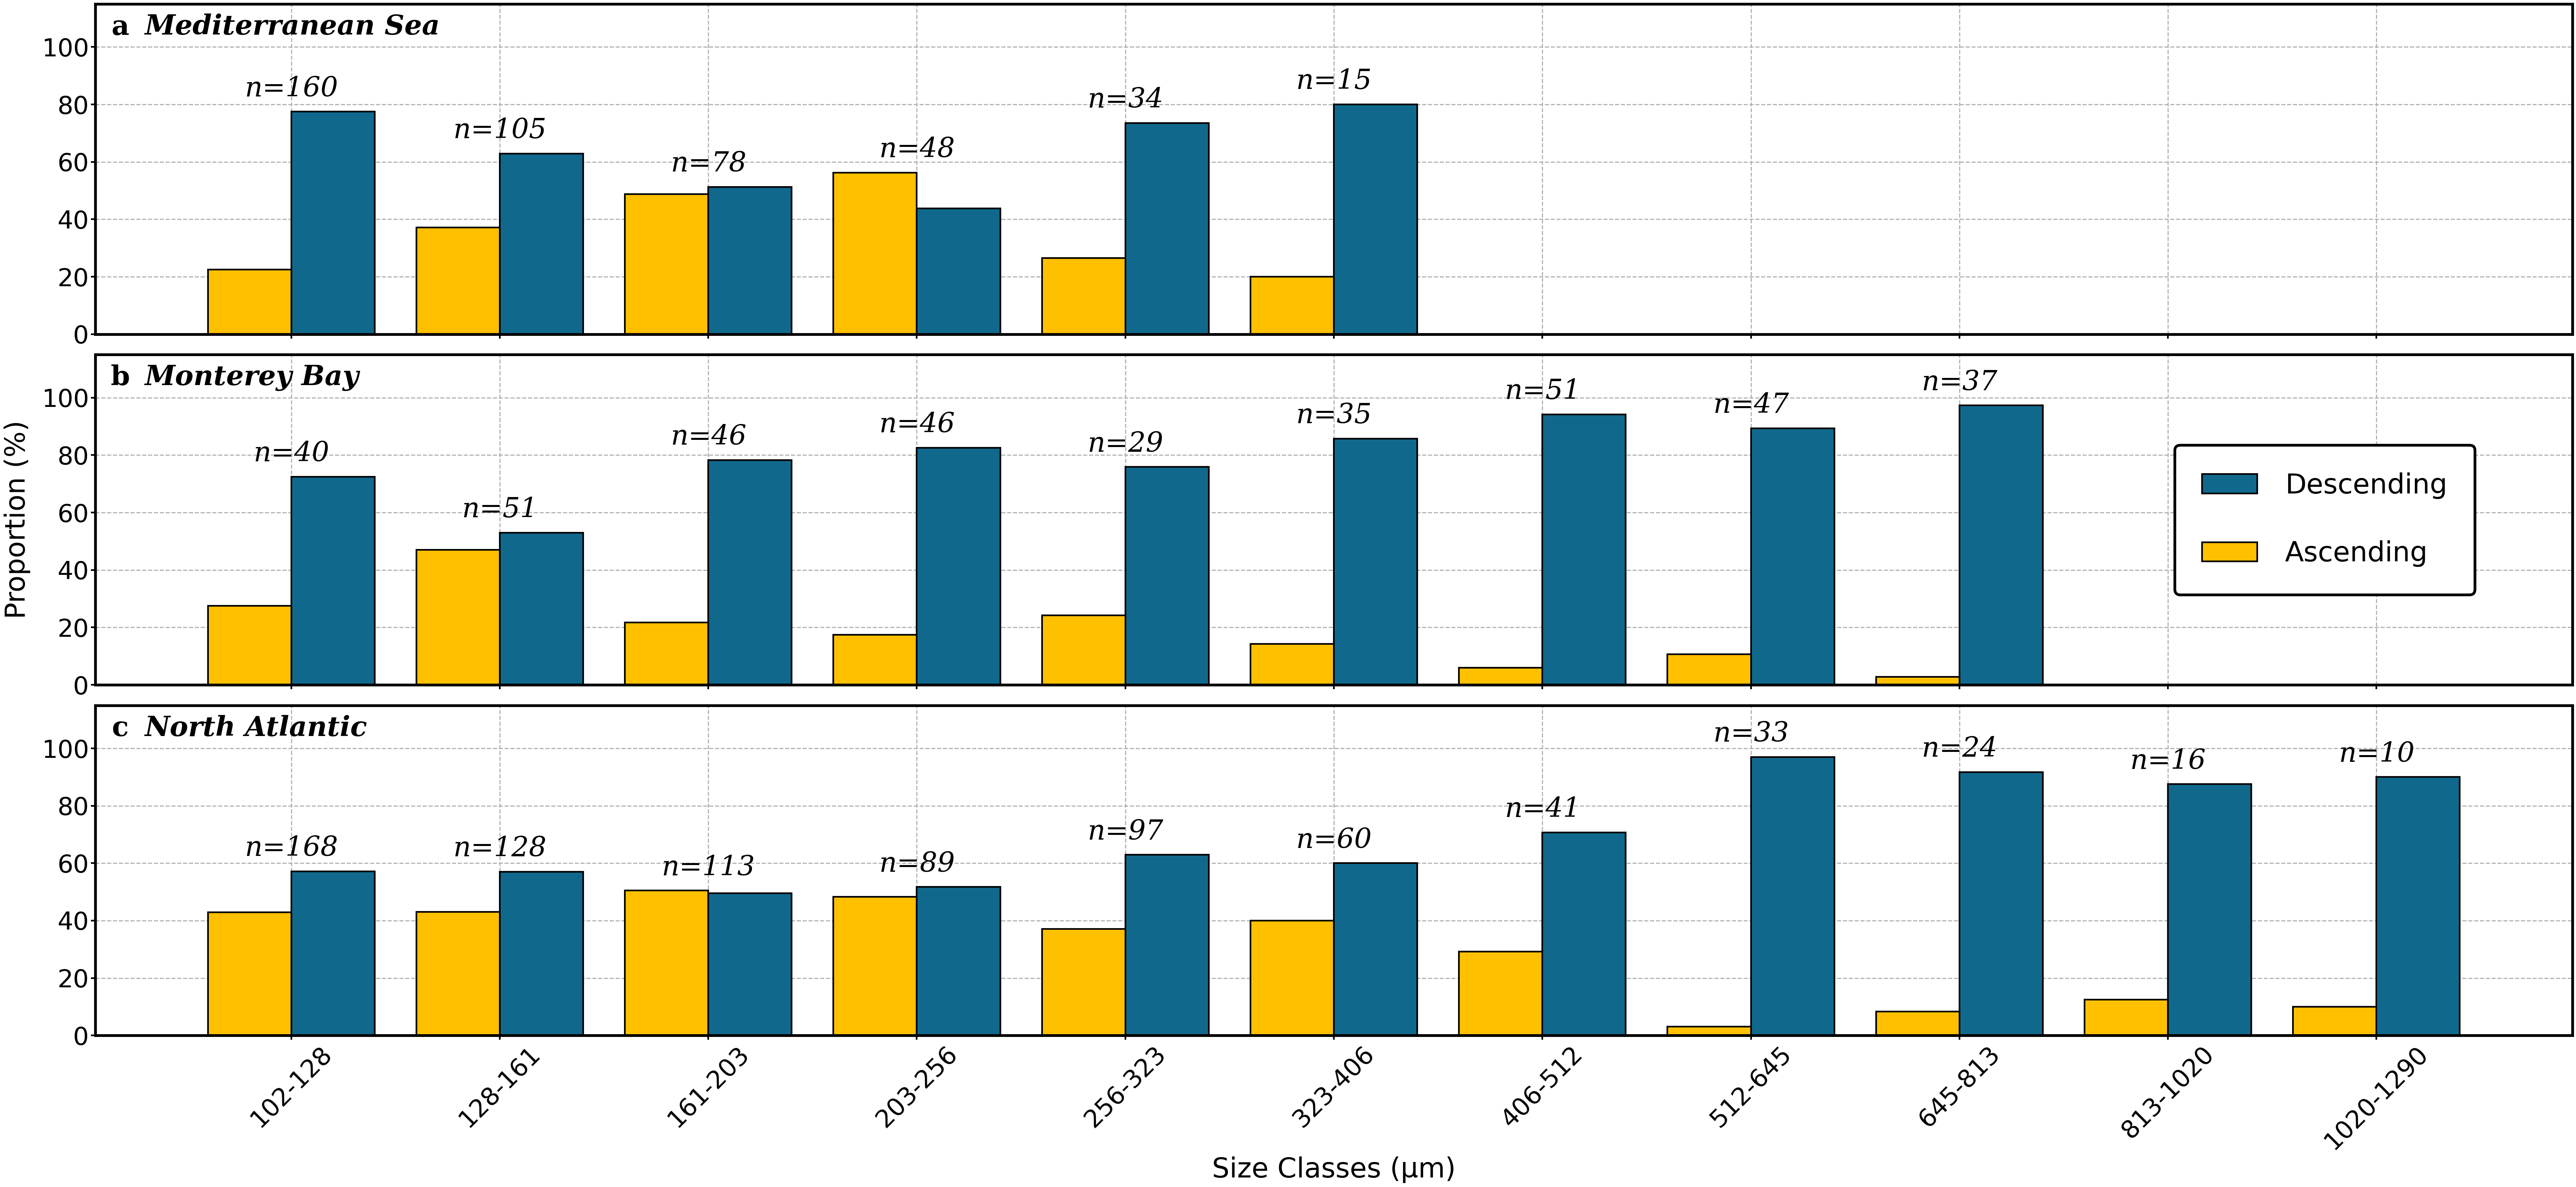

In [29]:
fig, axs = plt.subplots(3, 1, sharex=True, figsize=(65, 30))

plot_particle_proportions(ax = axs[0], df = nb_part_tot_VLFR, police_size = 50, subplot_indice = 'a', zone = 'Mediterranean Sea', show_legend = False, show_x_label = False, show_y_label = False)

plot_particle_proportions(ax = axs[1], df = nb_part_tot_MBARI, police_size = 50, subplot_indice = 'b', zone = 'Monterey Bay', show_legend = True, show_x_label = False, show_y_label = True)

plot_particle_proportions(ax = axs[2], df = nb_part_tot_APERO, police_size = 50, subplot_indice = 'c', zone = 'North Atlantic', show_legend = False, show_x_label = True, show_y_label = False)

plt.tight_layout()
plt.savefig(f'/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S9/Figure_S9.png', dpi = 300)
plt.show()